<a href="https://colab.research.google.com/github/hkiju9-dev/AI-Based-Skin-cancer-detection/blob/master/Skin_Cancer_Stage2_GAN_Augmentation.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Skin Cancer Detection — Stage 2: GAN-Based Augmentation for Class Imbalance

**Goal (from the proposal, Section 5):** Train a DCGAN on the malignant-class images only, generate
synthetic malignant samples, rebalance the training set with them, and retrain the same ResNet-50
classifier. Compare the result against the Stage 1 baseline — the target is to **raise malignant
precision without losing the 89% recall** achieved by class weighting alone.

**This notebook is self-contained** — it redownloads and re-splits the data with the same
`random_state=42` used in Stage 1, so your test set is identical and results are directly comparable.

**Steps:**
1. Setup + reload data (same split as Stage 1)
2. Isolate malignant training images, prepare them for GAN training (64×64, normalized to [-1, 1])
3. Build the DCGAN (Generator + Discriminator)
4. Train the DCGAN, visually inspect generated samples over time
5. Generate synthetic malignant images to balance the training set
6. Retrain the ResNet-50 classifier on the rebalanced (real + synthetic) data
7. Evaluate on the **same real test set** as Stage 1 and compare side-by-side
8. Save the GAN generator and the improved classifier


## 1. Setup

In [1]:
!pip install -q kagglehub tensorflow scikit-learn seaborn opencv-python-headless


In [2]:
import os, json, time
import numpy as np
import pandas as pd
import cv2
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split
from sklearn.metrics import classification_report, confusion_matrix, roc_auc_score
from sklearn.utils import class_weight

import tensorflow as tf
from tensorflow.keras import layers
from tensorflow.keras.applications import ResNet50
from tensorflow.keras.applications.resnet50 import preprocess_input
from tensorflow.keras.layers import Dense, GlobalAveragePooling2D, Dropout
from tensorflow.keras.models import Model, Sequential
from tensorflow.keras.optimizers import Adam
from tensorflow.keras.preprocessing.image import ImageDataGenerator
from tensorflow.keras.callbacks import EarlyStopping, ModelCheckpoint

print("TensorFlow version:", tf.__version__)
print("GPU available:", tf.config.list_physical_devices('GPU'))


TensorFlow version: 2.20.0
GPU available: [PhysicalDevice(name='/physical_device:GPU:0', device_type='GPU')]


## 2. Reload the Dataset & Recreate the Same Split as Stage 1

Same `random_state=42` guarantees the same train/val/test split, so the test set here is
identical to Stage 1's test set — this is essential for a fair comparison.


In [3]:
import kagglehub
dataset_path = kagglehub.dataset_download("kmader/skin-cancer-mnist-ham10000")

metadata_path = os.path.join(dataset_path, "HAM10000_metadata.csv")
df = pd.read_csv(metadata_path)

malignant_classes = ['mel', 'bcc', 'akiec']
df['binary_label'] = df['dx'].apply(lambda x: 'malignant' if x in malignant_classes else 'benign')

image_folders = [os.path.join(dataset_path, d) for d in os.listdir(dataset_path) if 'part' in d.lower()]
if not image_folders:
    image_folders = []
    for root, dirs, files in os.walk(dataset_path):
        if any(f.endswith('.jpg') for f in files):
            image_folders.append(root)

image_paths = {}
for folder in image_folders:
    for fname in os.listdir(folder):
        if fname.endswith('.jpg'):
            image_paths[fname.replace('.jpg', '')] = os.path.join(folder, fname)

df['image_path'] = df['image_id'].map(image_paths)
df = df.dropna(subset=['image_path']).reset_index(drop=True)

IMG_SIZE = 224  # classifier input size

train_df, temp_df = train_test_split(df, test_size=0.3, stratify=df['binary_label'], random_state=42)
val_df, test_df = train_test_split(temp_df, test_size=0.5, stratify=temp_df['binary_label'], random_state=42)

print("Train:", len(train_df), "| Val:", len(val_df), "| Test:", len(test_df))
print(train_df['binary_label'].value_counts())


Using Colab cache for faster access to the 'skin-cancer-mnist-ham10000' dataset.
Train: 7010 | Val: 1502 | Test: 1503
binary_label
benign       5642
malignant    1368
Name: count, dtype: int64


## 3. Prepare Malignant Images for GAN Training

DCGANs train faster and more stably at a smaller resolution (64×64). We train the GAN only on the
**malignant training images** (never touching val/test), then upscale generated samples to 224×224
before feeding them to the classifier later.


In [4]:
GAN_IMG_SIZE = 64

malignant_train_df = train_df[train_df['binary_label'] == 'malignant'].reset_index(drop=True)
print("Malignant training images available for GAN training:", len(malignant_train_df))

def load_gan_image(path, size=GAN_IMG_SIZE):
    img = cv2.imread(path)
    img = cv2.cvtColor(img, cv2.COLOR_BGR2RGB)
    img = cv2.resize(img, (size, size))
    return img

print("Loading malignant images into memory for GAN training...")
gan_images = np.array([load_gan_image(p) for p in malignant_train_df['image_path']])
gan_images = (gan_images.astype('float32') - 127.5) / 127.5  # normalize to [-1, 1] for tanh output
print("GAN training data shape:", gan_images.shape)

BUFFER_SIZE = len(gan_images)
GAN_BATCH_SIZE = 32
gan_dataset = tf.data.Dataset.from_tensor_slices(gan_images).shuffle(BUFFER_SIZE).batch(GAN_BATCH_SIZE)


Malignant training images available for GAN training: 1368
Loading malignant images into memory for GAN training...
GAN training data shape: (1368, 64, 64, 3)


## 4. Build the DCGAN

**Generator:** takes random noise (100-dim vector) → upsamples through transposed convolutions →
outputs a 64×64×3 fake image.

**Discriminator:** takes a 64×64×3 image (real or fake) → downsamples through convolutions →
outputs a single "real vs fake" probability.


In [5]:
NOISE_DIM = 100

def build_generator():
    model = Sequential([
        layers.Dense(8 * 8 * 256, use_bias=False, input_shape=(NOISE_DIM,)),
        layers.BatchNormalization(),
        layers.LeakyReLU(0.2),
        layers.Reshape((8, 8, 256)),

        layers.Conv2DTranspose(128, 5, strides=2, padding='same', use_bias=False),  # 16x16
        layers.BatchNormalization(),
        layers.LeakyReLU(0.2),

        layers.Conv2DTranspose(64, 5, strides=2, padding='same', use_bias=False),   # 32x32
        layers.BatchNormalization(),
        layers.LeakyReLU(0.2),

        layers.Conv2DTranspose(3, 5, strides=2, padding='same', use_bias=False,      # 64x64
                                activation='tanh'),
    ])
    return model

def build_discriminator():
    model = Sequential([
        layers.Conv2D(64, 5, strides=2, padding='same', input_shape=(GAN_IMG_SIZE, GAN_IMG_SIZE, 3)),
        layers.LeakyReLU(0.2),
        layers.Dropout(0.3),

        layers.Conv2D(128, 5, strides=2, padding='same'),
        layers.LeakyReLU(0.2),
        layers.Dropout(0.3),

        layers.Conv2D(256, 5, strides=2, padding='same'),
        layers.LeakyReLU(0.2),
        layers.Dropout(0.3),

        layers.Flatten(),
        layers.Dense(1),  # no activation — using logits with from_logits=True in the loss
    ])
    return model

generator = build_generator()
discriminator = build_discriminator()

generator.summary()
discriminator.summary()


/usr/local/lib/python3.13/dist-packages/keras/src/layers/core/dense.py:106: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)
/usr/local/lib/python3.13/dist-packages/keras/src/layers/convolutional/base_conv.py:113: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ dense (Dense)                   │ (None, 16384)          │     1,638,400 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization             │ (None, 16384)          │        65,536 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ leaky_re_lu (LeakyReLU)         │ (None, 16384)          │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ reshape (Reshape)               │ (None, 8, 8, 256)      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_transpose                │ (None, 16, 16, 128)    │       819,200 │
│ (Conv2DTranspose)               │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_1           │ (None, 16, 16, 128)    │           512 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ leaky_re_lu_1 (LeakyReLU)       │ (None, 16, 16, 128)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_transpose_1              │ (None, 32, 32, 64)     │       204,800 │
│ (Conv2DTranspose)               │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_2           │ (None, 32, 32, 64)     │           256 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ leaky_re_lu_2 (LeakyReLU)       │ (None, 32, 32, 64)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_transpose_2              │ (None, 64, 64, 3)      │         4,800 │
│ (Conv2DTranspose)               │                        │               │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 2,733,504 (10.43 MB)

 Trainable params: 2,700,352 (10.30 MB)

...

Model: "sequential_1"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ conv2d (Conv2D)                 │ (None, 32, 32, 64)     │         4,864 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ leaky_re_lu_3 (LeakyReLU)       │ (None, 32, 32, 64)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 32, 32, 64)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_1 (Conv2D)               │ (None, 16, 16, 128)    │       204,928 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ leaky_re_lu_4 (LeakyReLU)       │ (None, 16, 16, 128)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_1 (Dropout)             │ (None, 16, 16, 128)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_2 (Conv2D)               │ (None, 8, 8, 256)      │       819,456 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ leaky_re_lu_5 (LeakyReLU)       │ (None, 8, 8, 256)      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_2 (Dropout)             │ (None, 8, 8, 256)      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten (Flatten)               │ (None, 16384)          │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 1)              │        16,385 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 1,045,633 (3.99 MB)

 Trainable params: 1,045,633 (3.99 MB)

 Non-trainable params: 0 (0.00 B)

## 5. Define GAN Losses, Optimizers & the Training Step

In [6]:
cross_entropy = tf.keras.losses.BinaryCrossentropy(from_logits=True)

def discriminator_loss(real_output, fake_output):
    real_loss = cross_entropy(tf.ones_like(real_output), real_output)
    fake_loss = cross_entropy(tf.zeros_like(fake_output), fake_output)
    return real_loss + fake_loss

def generator_loss(fake_output):
    return cross_entropy(tf.ones_like(fake_output), fake_output)

generator_optimizer = Adam(learning_rate=2e-4, beta_1=0.5)
discriminator_optimizer = Adam(learning_rate=2e-4, beta_1=0.5)

@tf.function
def train_step(real_images):
    noise = tf.random.normal([real_images.shape[0], NOISE_DIM])

    with tf.GradientTape() as gen_tape, tf.GradientTape() as disc_tape:
        fake_images = generator(noise, training=True)

        real_output = discriminator(real_images, training=True)
        fake_output = discriminator(fake_images, training=True)

        gen_loss = generator_loss(fake_output)
        disc_loss = discriminator_loss(real_output, fake_output)

    gen_gradients = gen_tape.gradient(gen_loss, generator.trainable_variables)
    disc_gradients = disc_tape.gradient(disc_loss, discriminator.trainable_variables)

    generator_optimizer.apply_gradients(zip(gen_gradients, generator.trainable_variables))
    discriminator_optimizer.apply_gradients(zip(disc_gradients, discriminator.trainable_variables))

    return gen_loss, disc_loss


## 6. Train the DCGAN

We periodically save a grid of generated images so you can visually confirm the generator is
producing increasingly realistic lesion-like textures rather than noise.


Epoch 1/150 | Gen loss: 1.7885 | Disc loss: 0.7359 | Time: 10.7s


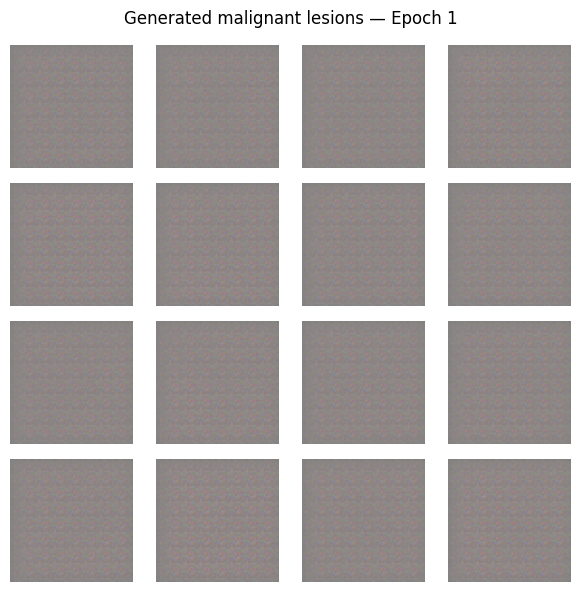

Epoch 25/150 | Gen loss: 1.0089 | Disc loss: 1.2455 | Time: 1.8s


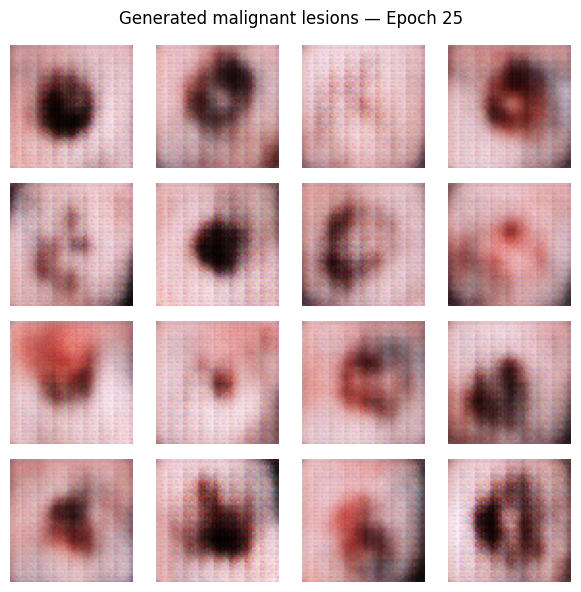

Epoch 50/150 | Gen loss: 0.7777 | Disc loss: 1.3340 | Time: 1.8s


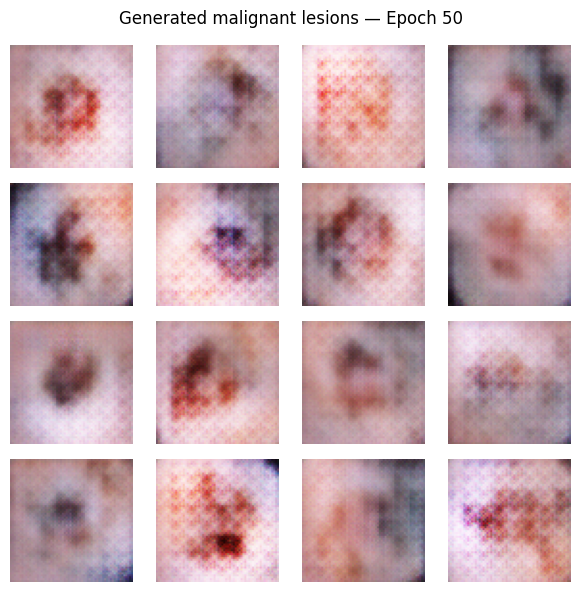

Epoch 75/150 | Gen loss: 0.7320 | Disc loss: 1.3411 | Time: 1.8s


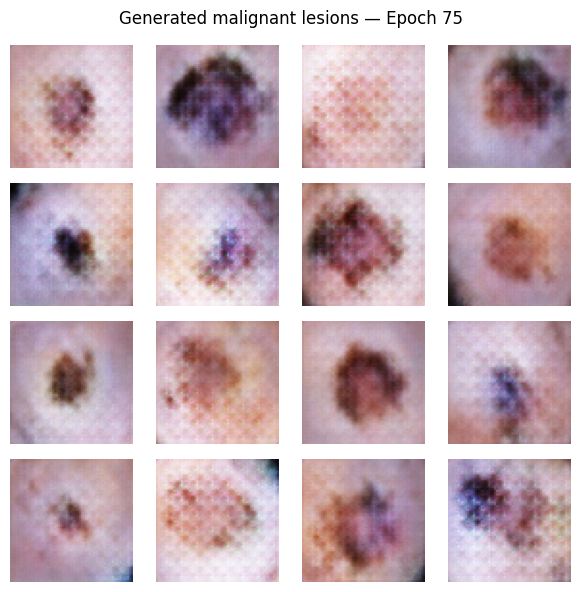

Epoch 100/150 | Gen loss: 0.7376 | Disc loss: 1.3583 | Time: 1.8s


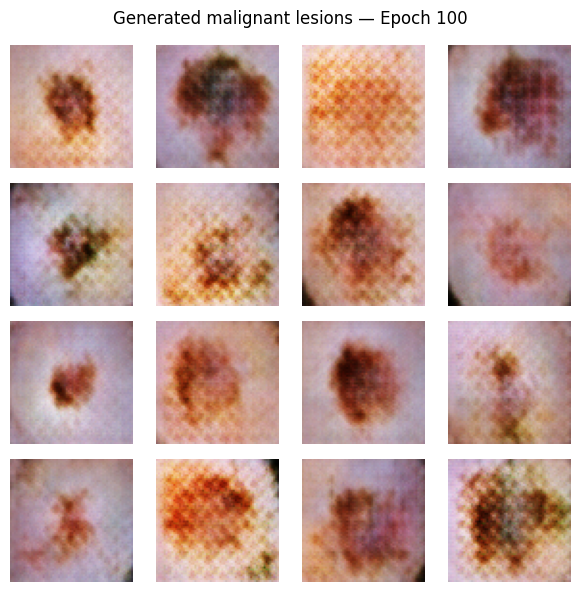

Epoch 125/150 | Gen loss: 0.7341 | Disc loss: 1.3494 | Time: 1.8s


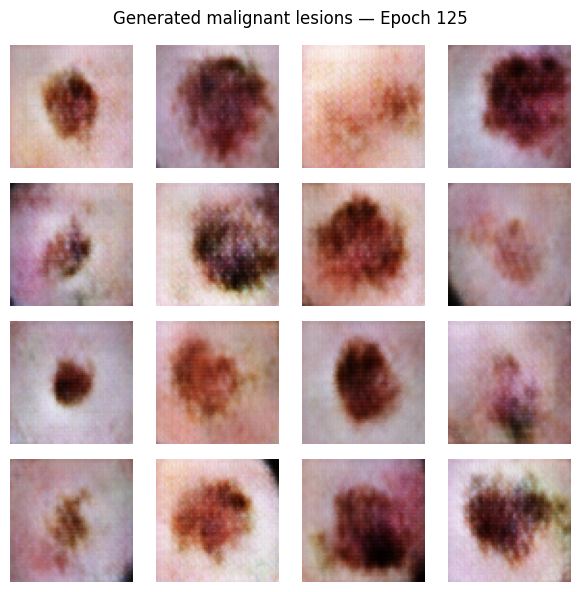

Epoch 150/150 | Gen loss: 0.7525 | Disc loss: 1.3235 | Time: 1.8s


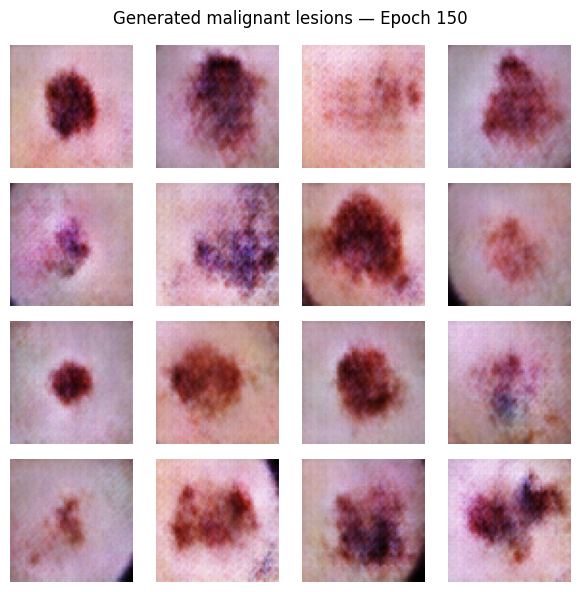

GAN training complete.


In [7]:
GAN_EPOCHS = 150  # DCGANs need more epochs than classifiers; adjust based on time available
seed = tf.random.normal([16, NOISE_DIM])  # fixed seed to track the same images across epochs

def generate_and_plot(model, epoch, test_input):
    predictions = model(test_input, training=False)
    predictions = (predictions + 1) / 2.0  # back to [0, 1] for display

    fig = plt.figure(figsize=(6, 6))
    for i in range(predictions.shape[0]):
        plt.subplot(4, 4, i + 1)
        plt.imshow(predictions[i])
        plt.axis('off')
    plt.suptitle(f"Generated malignant lesions — Epoch {epoch}")
    plt.tight_layout()
    plt.savefig(f"gan_epoch_{epoch:03d}.png", dpi=100)
    plt.show()

gen_losses, disc_losses = [], []

for epoch in range(1, GAN_EPOCHS + 1):
    start = time.time()
    epoch_gen_loss, epoch_disc_loss = [], []

    for image_batch in gan_dataset:
        g_loss, d_loss = train_step(image_batch)
        epoch_gen_loss.append(g_loss.numpy())
        epoch_disc_loss.append(d_loss.numpy())

    gen_losses.append(np.mean(epoch_gen_loss))
    disc_losses.append(np.mean(epoch_disc_loss))

    if epoch % 25 == 0 or epoch == 1:
        print(f"Epoch {epoch}/{GAN_EPOCHS} | Gen loss: {gen_losses[-1]:.4f} | "
              f"Disc loss: {disc_losses[-1]:.4f} | Time: {time.time()-start:.1f}s")
        generate_and_plot(generator, epoch, seed)

print("GAN training complete.")


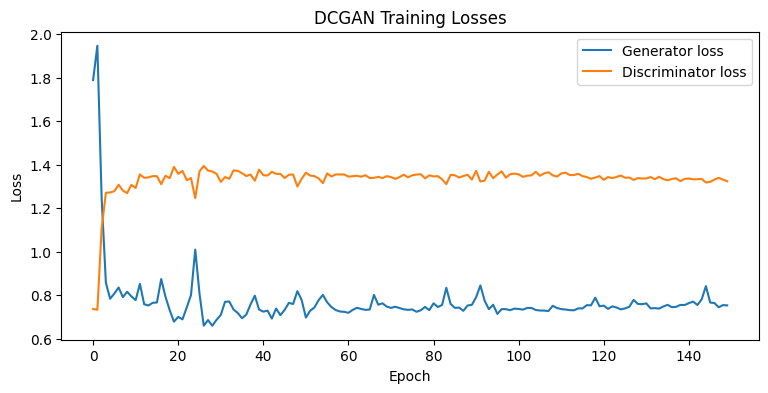

In [8]:
# Plot GAN training curves.
# Healthy sign: both losses fluctuate and roughly stabilize (neither collapses to ~0).
# Warning sign: discriminator loss -> 0 while generator loss keeps rising = mode collapse / discriminator "winning".
plt.figure(figsize=(9, 4))
plt.plot(gen_losses, label='Generator loss')
plt.plot(disc_losses, label='Discriminator loss')
plt.xlabel('Epoch'); plt.ylabel('Loss'); plt.legend()
plt.title('DCGAN Training Losses')
plt.savefig("gan_loss_curves.png", dpi=150)
plt.show()


## 7. Generate Synthetic Malignant Images to Rebalance the Training Set

We generate enough synthetic malignant images so that, combined with the real ones, the training
set is roughly balanced with the benign class — directly targeting the P1 imbalance problem with
real (synthetic) data rather than only a loss-function weight.


Benign (train): 5642 | Malignant (train): 1368
Synthetic malignant images to generate: 4274
Generated 4274 synthetic malignant images -> saved in 'synthetic_malignant/'


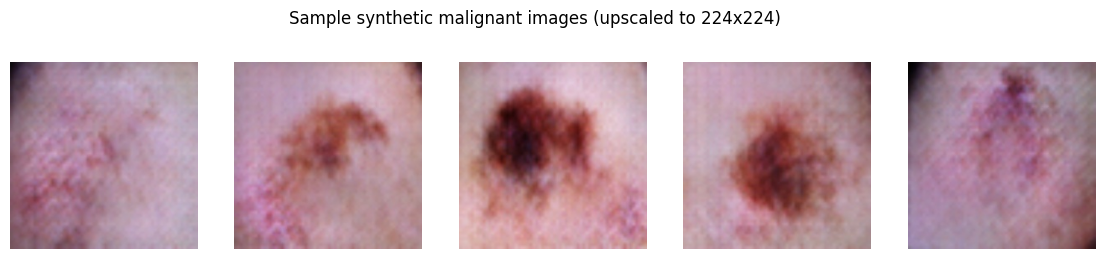

In [9]:
benign_count = (train_df['binary_label'] == 'benign').sum()
malignant_count = (train_df['binary_label'] == 'malignant').sum()
num_synthetic_needed = benign_count - malignant_count

print(f"Benign (train): {benign_count} | Malignant (train): {malignant_count}")
print(f"Synthetic malignant images to generate: {num_synthetic_needed}")

synthetic_dir = "synthetic_malignant"
os.makedirs(synthetic_dir, exist_ok=True)

synthetic_paths = []
batch = 100
generated = 0
while generated < num_synthetic_needed:
    n = min(batch, num_synthetic_needed - generated)
    noise = tf.random.normal([n, NOISE_DIM])
    fake_imgs = generator(noise, training=False).numpy()
    fake_imgs = ((fake_imgs + 1) * 127.5).astype('uint8')  # back to [0, 255]

    for img in fake_imgs:
        img_resized = cv2.resize(img, (IMG_SIZE, IMG_SIZE))  # upscale to classifier input size
        img_bgr = cv2.cvtColor(img_resized, cv2.COLOR_RGB2BGR)
        fname = os.path.join(synthetic_dir, f"synthetic_{generated}.jpg")
        cv2.imwrite(fname, img_bgr)
        synthetic_paths.append(fname)
        generated += 1

print(f"Generated {generated} synthetic malignant images -> saved in '{synthetic_dir}/'")

# Visual sanity check: a few synthetic images at full classifier resolution
fig, axes = plt.subplots(1, 5, figsize=(14, 3))
for ax, p in zip(axes, synthetic_paths[:5]):
    img = cv2.cvtColor(cv2.imread(p), cv2.COLOR_BGR2RGB)
    ax.imshow(img); ax.axis('off')
plt.suptitle("Sample synthetic malignant images (upscaled to 224x224)")
plt.savefig("synthetic_samples.png", dpi=150)
plt.show()


## 8. Build the Rebalanced Training Set (Real + Synthetic)

The validation and test sets remain **100% real, untouched** — synthetic images are only ever added
to training data, never used to evaluate the model.


In [10]:
synthetic_df = pd.DataFrame({
    'image_path': synthetic_paths,
    'binary_label': ['malignant'] * len(synthetic_paths)
})

augmented_train_df = pd.concat(
    [train_df[['image_path', 'binary_label']], synthetic_df],
    ignore_index=True
)

print("Rebalanced training set:")
print(augmented_train_df['binary_label'].value_counts())


Rebalanced training set:
binary_label
benign       5642
malignant    5642
Name: count, dtype: int64


## 9. Rebuild Data Generators with the Rebalanced Training Set

In [11]:
train_datagen = ImageDataGenerator(
    preprocessing_function=preprocess_input,
    rotation_range=30, width_shift_range=0.1, height_shift_range=0.1,
    horizontal_flip=True, vertical_flip=True, brightness_range=[0.8, 1.2], zoom_range=0.15,
)
val_test_datagen = ImageDataGenerator(preprocessing_function=preprocess_input)

BATCH_SIZE = 32

train_generator = train_datagen.flow_from_dataframe(
    augmented_train_df, x_col='image_path', y_col='binary_label',
    target_size=(IMG_SIZE, IMG_SIZE), batch_size=BATCH_SIZE, class_mode='binary', shuffle=True
)
val_generator = val_test_datagen.flow_from_dataframe(
    val_df, x_col='image_path', y_col='binary_label',
    target_size=(IMG_SIZE, IMG_SIZE), batch_size=BATCH_SIZE, class_mode='binary', shuffle=False
)
test_generator = val_test_datagen.flow_from_dataframe(
    test_df, x_col='image_path', y_col='binary_label',
    target_size=(IMG_SIZE, IMG_SIZE), batch_size=BATCH_SIZE, class_mode='binary', shuffle=False
)

print("Class mapping:", train_generator.class_indices)


Found 11284 validated image filenames belonging to 2 classes.
Found 1502 validated image filenames belonging to 2 classes.
Found 1503 validated image filenames belonging to 2 classes.
Class mapping: {'benign': 0, 'malignant': 1}


## 10. Retrain the Classifier on the Rebalanced Data

Same ResNet-50 architecture as Stage 1 — the only difference is the training data. This isolates
the effect of GAN augmentation as a fair, controlled comparison against the baseline.

Note: since the data is now naturally balanced, we no longer need the `class_weight` argument from
Stage 1.


In [12]:
base_model = ResNet50(weights='imagenet', include_top=False, input_shape=(IMG_SIZE, IMG_SIZE, 3))
base_model.trainable = False

x = base_model.output
x = GlobalAveragePooling2D()(x)
x = Dense(128, activation='relu')(x)
x = Dropout(0.4)(x)
output = Dense(1, activation='sigmoid')(x)

gan_augmented_model = Model(inputs=base_model.input, outputs=output)

gan_augmented_model.compile(
    optimizer=Adam(learning_rate=1e-4),
    loss='binary_crossentropy',
    metrics=['accuracy', tf.keras.metrics.AUC(name='auc'),
             tf.keras.metrics.Precision(name='precision'),
             tf.keras.metrics.Recall(name='recall')]
)

callbacks = [
    EarlyStopping(monitor='val_auc', mode='max', patience=5, restore_best_weights=True),
    ModelCheckpoint('gan_augmented_resnet50.keras', monitor='val_auc', mode='max', save_best_only=True)
]

history = gan_augmented_model.fit(
    train_generator, validation_data=val_generator, epochs=20, callbacks=callbacks
)


94765736/94765736 ━━━━━━━━━━━━━━━━━━━━ 6s 0us/step
Epoch 1/20
353/353 ━━━━━━━━━━━━━━━━━━━━ 299s 805ms/step - accuracy: 0.8667 - auc: 0.9393 - loss: 0.3066 - precision: 0.8829 - recall: 0.8456 - val_accuracy: 0.8216 - val_auc: 0.8512 - val_loss: 0.3704 - val_precision: 0.6033 - val_recall: 0.2491
Epoch 2/20
353/353 ━━━━━━━━━━━━━━━━━━━━ 223s 631ms/step - accuracy: 0.8945 - auc: 0.9640 - loss: 0.2294 - precision: 0.9202 - recall: 0.8641 - val_accuracy: 0.8375 - val_auc: 0.8670 - val_loss: 0.3496 - val_precision: 0.6485 - val_recall: 0.3652
Epoch 3/20
353/353 ━━━━━━━━━━━━━━━━━━━━ 224s 633ms/step - accuracy: 0.9003 - auc: 0.9684 - loss: 0.2143 - precision: 0.9254 - recall: 0.8708 - val_accuracy: 0.8342 - val_auc: 0.8715 - val_loss: 0.3519 - val_precision: 0.6719 - val_recall: 0.2935
Epoch 4/20
353/353 ━━━━━━━━━━━━━━━━━━━━ 221s 627ms/step - accuracy: 0.9041 - auc: 0.9697 - loss: 0.2086 - precision: 0.9326 - recall: 0.8711 - val_accuracy: 0.8389 - val_auc: 0.8802 - val_loss: 0.3518 - val_prec

## 11. Evaluate on the Same Real Test Set as Stage 1

47/47 ━━━━━━━━━━━━━━━━━━━━ 32s 587ms/step
=== Classification Report (GAN-Augmented Model) ===
              precision    recall  f1-score   support

      benign       0.90      0.94      0.92      1210
   malignant       0.70      0.57      0.63       293

    accuracy                           0.87      1503
   macro avg       0.80      0.76      0.78      1503
weighted avg       0.86      0.87      0.86      1503

AUC-ROC: 0.9079


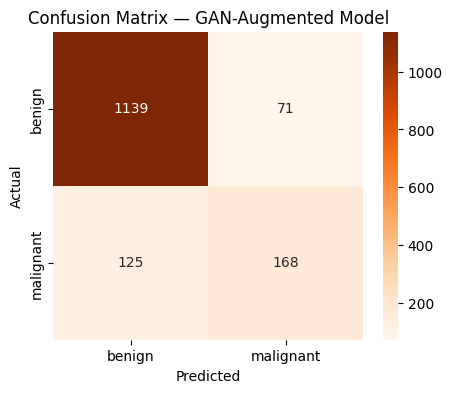

In [13]:
test_generator.reset()
y_pred_prob = gan_augmented_model.predict(test_generator)
y_pred = (y_pred_prob > 0.5).astype(int).flatten()
y_true = test_generator.classes

print("=== Classification Report (GAN-Augmented Model) ===")
print(classification_report(y_true, y_pred, target_names=list(test_generator.class_indices.keys())))

gan_auc_score = roc_auc_score(y_true, y_pred_prob)
print(f"AUC-ROC: {gan_auc_score:.4f}")

cm = confusion_matrix(y_true, y_pred)
plt.figure(figsize=(5, 4))
sns.heatmap(cm, annot=True, fmt='d', cmap='Oranges',
            xticklabels=test_generator.class_indices.keys(),
            yticklabels=test_generator.class_indices.keys())
plt.title("Confusion Matrix — GAN-Augmented Model")
plt.xlabel("Predicted"); plt.ylabel("Actual")
plt.savefig("confusion_matrix_gan.png", dpi=150)
plt.show()


## 12. Side-by-Side Comparison: Baseline (Stage 1) vs GAN-Augmented (Stage 2)

If you ran Stage 1 in the same session, `baseline_results.json` will already exist. Otherwise,
upload it from Stage 1's outputs, or just re-enter the numbers manually below.


baseline_results.json not found in this session — enter Stage 1's AUC manually below.
             Metric  Stage 1 - Baseline (class weighting)  Stage 2 - GAN-Augmented  Improvement
            AUC-ROC                                0.9112                 0.907881    -0.003319
Malignant Precision                                0.4700                 0.702929     0.232929
   Malignant Recall                                0.8900                 0.573379    -0.316621
 Malignant F1-score                                0.6200                 0.631579     0.011579


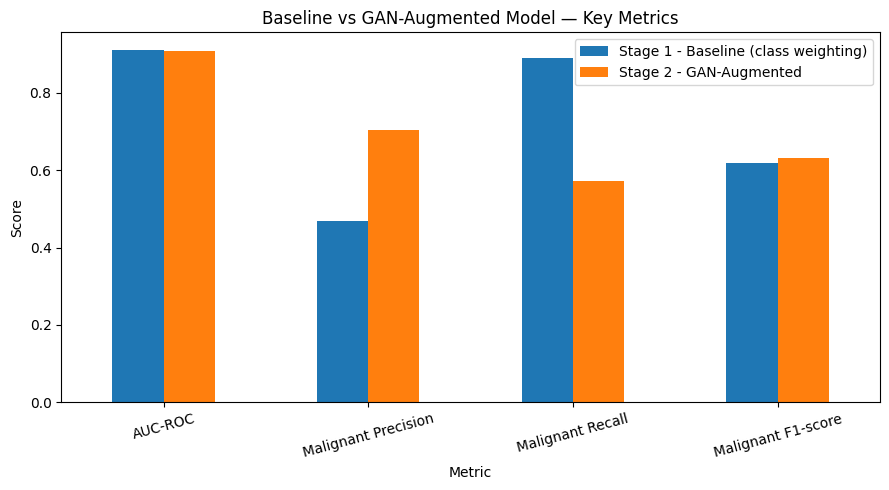

In [14]:
try:
    with open("baseline_results.json") as f:
        baseline_results = json.load(f)
    baseline_auc = baseline_results['test_auc']
except FileNotFoundError:
    print("baseline_results.json not found in this session — enter Stage 1's AUC manually below.")
    baseline_auc = 0.9112  # replace with your actual Stage 1 AUC if different

from sklearn.metrics import precision_score, recall_score, f1_score

comparison = pd.DataFrame({
    'Metric': ['AUC-ROC', 'Malignant Precision', 'Malignant Recall', 'Malignant F1-score'],
    'Stage 1 - Baseline (class weighting)': [
        baseline_auc, 0.47, 0.89, 0.62  # from the Stage 1 results you shared
    ],
    'Stage 2 - GAN-Augmented': [
        gan_auc_score,
        precision_score(y_true, y_pred, pos_label=1),
        recall_score(y_true, y_pred, pos_label=1),
        f1_score(y_true, y_pred, pos_label=1),
    ]
})
comparison['Improvement'] = comparison['Stage 2 - GAN-Augmented'] - comparison['Stage 1 - Baseline (class weighting)']
print(comparison.to_string(index=False))

comparison.set_index('Metric')[['Stage 1 - Baseline (class weighting)', 'Stage 2 - GAN-Augmented']].plot(
    kind='bar', figsize=(9, 5), rot=15
)
plt.title("Baseline vs GAN-Augmented Model — Key Metrics")
plt.ylabel("Score")
plt.tight_layout()
plt.savefig("stage1_vs_stage2_comparison.png", dpi=150)
plt.show()


## 13. Save the GAN Generator, Classifier, and Results

In [15]:
generator.save("dcgan_generator_malignant.keras")
gan_augmented_model.save("gan_augmented_resnet50_final.keras")

gan_results_summary = {
    "model": "ResNet-50 + DCGAN-augmented rebalanced training data",
    "test_auc": float(gan_auc_score),
    "malignant_precision": float(precision_score(y_true, y_pred, pos_label=1)),
    "malignant_recall": float(recall_score(y_true, y_pred, pos_label=1)),
    "malignant_f1": float(f1_score(y_true, y_pred, pos_label=1)),
    "synthetic_images_generated": int(num_synthetic_needed),
}
with open("gan_augmented_results.json", "w") as f:
    json.dump(gan_results_summary, f, indent=2)

print("Saved: dcgan_generator_malignant.keras, gan_augmented_resnet50_final.keras, gan_augmented_results.json")
print(gan_results_summary)


Saved: dcgan_generator_malignant.keras, gan_augmented_resnet50_final.keras, gan_augmented_results.json
{'model': 'ResNet-50 + DCGAN-augmented rebalanced training data', 'test_auc': 0.9078808563450201, 'malignant_precision': 0.702928870292887, 'malignant_recall': 0.5733788395904437, 'malignant_f1': 0.631578947368421, 'synthetic_images_generated': 4274}


---
## How to Read Your Results

- **If Stage 2 precision > Stage 1 precision, with recall staying close to 0.89** → the GAN
  successfully reduced false alarms without sacrificing cancer detection. This is the target outcome.
- **If recall drops a lot** → the GAN may need more training epochs, or the synthetic images are not
  diverse enough (check `synthetic_samples.png` — do they look like plausible lesions or still noisy?).
- **If the discriminator loss collapsed to near 0 early in training** → classic GAN failure mode
  (discriminator "wins" too easily). Fixes: lower the discriminator's learning rate, add label
  smoothing, or add noise to discriminator inputs.

## Next Steps

1. **Stage 3 — Few-shot learning (Prototypical Network):** for the rarest original classes
   (`df`, `vasc`) where even GAN augmentation has very little real data to learn from.
2. **Fine-tuning:** unfreeze the top ResNet-50 layers and fine-tune at a lower learning rate for a
   further boost on top of the GAN-augmented result.
3. Report these Stage 1 vs Stage 2 numbers in your thesis/paper's **Results** section — this
   comparison table is exactly the kind of evidence journals expect for the "combination of CNN and
   GAN models" contribution described in the reviewed paper.

Let me know your Stage 2 numbers and I'll help interpret them and decide whether to move to Stage 3.
